In [16]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### Part a

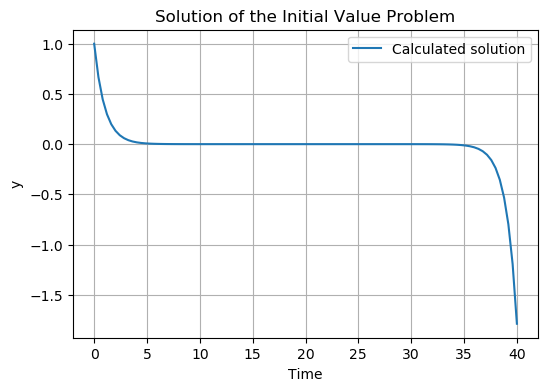

In [32]:
def ivp(t, y): 
    return - abs(y)
def exact(t): return np.exp(-t)
y0 = 1
tspan = [0, 40]
sol = solve_ivp(ivp, tspan, [y0], method='RK45', t_eval=np.linspace(tspan[0], tspan[1], 100))

plt.figure(figsize=(6, 4))
plt.plot(sol.t, sol.y[0], label='Calculated solution')
#plt.plot(sol.t, exact(sol.t), label='exact solution')
plt.title('Solution of the Initial Value Problem')
plt.xlabel('Time')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()



When solving this numerically with an adaptive solver like RK45, the solver may encounter difficulties when y becomes negative. This is because the absolute value function abs(y) causes the right-hand side of the equation to switch signs abruptly when y crosses zero. Adaptive solvers, such as RK45, may not handle such discontinuities well, leading to numerical instability.

As a result, during the numerical integration, the solution may become negative, and the solver may encounter difficulties accurately computing the solution. Eventually, the numerical solution may "blow up," meaning it becomes extremely large or small, leading to numerical instability and inaccurate results.

## Part b

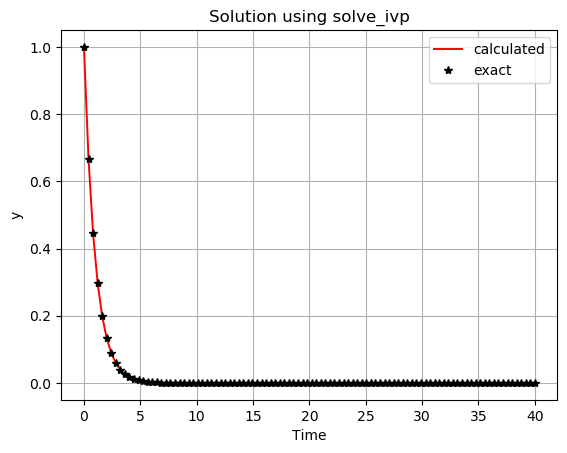

In [43]:
# Define the differential equation dy/dt = -1
def dydt(t, Y):
    return -1

# Define the time interval and initial condition
tspan = [0, 40]
Y0 = 0

# Solve the differential equation using solve_ivp
sol = solve_ivp(dydt, tspan, [Y0], method='RK45', t_eval=np.linspace(tspan[0], tspan[1], 100))

# Plot the solution
plt.figure(2)
y = np.exp(sol.y[0])
plt.plot(sol.t, y, 'red', linewidth=1.4, label='calculated')
plt.plot(sol.t, exact(sol.t), 'k*', linewidth=1.4, label='exact')
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('y')
plt.legend()
plt.title('Solution using solve_ivp')
plt.show()


### Part c

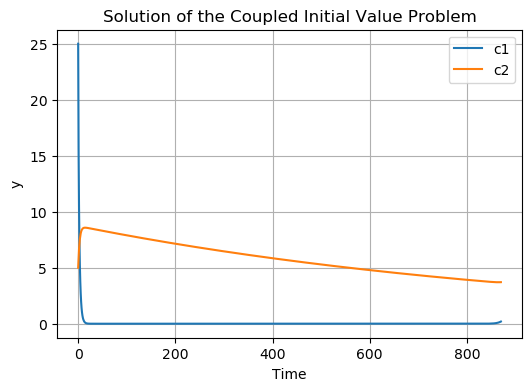

In [50]:
def ivp_2(t,c):
    dc1dt = 0.5 * c[0] * (1.0 - 0.05 * c[0]) - 0.1 * c[0] * c[1]
    dc2dt = 0.01 * c[0] * c[1] - 0.001 * c[1]
    return [dc1dt, dc2dt]

c0 = [25, 5]    
ti = 0
tf = 870
sol = solve_ivp(ivp_2, [ti, tf], c0, method='RK45', t_eval=np.linspace(ti, tf, 1000))

plt.figure(figsize=(6, 4))
plt.plot(sol.t, (sol.y[0]), label='c1')
plt.plot(sol.t, (sol.y[1]), label='c2')
plt.title('Solution of the Coupled Initial Value Problem')
plt.xlabel('Time')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

### Part d

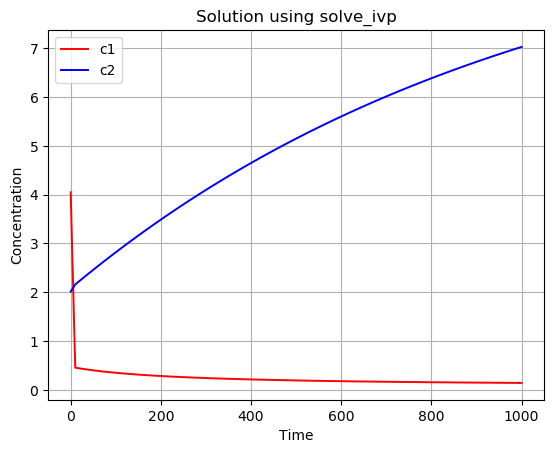

In [51]:
# Part d
tspan = [0, 1000]
y10 = 1.39794
y20 = 0.69897

# Define the differential equations as functions
def dy1dt(t, y):
    return 0.5*(1-0.05*np.exp(y[0]))*np.exp(-y[0]) - 0.5*np.exp(y[1])

def dy2dt(t, y):
    return 0.01*np.exp(y[0]) - 0.001

# Solve the differential equations using solve_ivp
sol_d = solve_ivp(lambda t, y: [dy1dt(t, y), dy2dt(t, y)], tspan, [y10, y20], method='RK45', t_eval=np.linspace(tspan[0], tspan[1], 100))

plt.figure(4)
plt.plot(sol_d.t, np.exp(sol_d.y[0]), 'red', linewidth=1.4, label='c1')
plt.plot(sol_d.t, np.exp(sol_d.y[1]), 'blue', linewidth=1.4, label='c2')
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Solution using solve_ivp')
plt.legend()
plt.show()